In [41]:
# import libraries
install.packages("scatterplot3d")
install


The downloaded binary packages are in
	/var/folders/m6/dcl8wc7d7vl_0n7g9854wdlw0000gp/T//Rtmpf110lm/downloaded_packages


In [1]:
library(tidyverse)
library(scatterplot3d)
library(car)

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘tibble’ was built under R version 4.5.2”
Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”
Warning message:
“package ‘dplyr’ was built under R version 4.5.2”
Warning message:
“package ‘lubridate’ was built under R version 4.5.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
gbsg_data <- read_csv("data/gbsg.csv")

New names:
• `` -> `...1`
Rows: 686 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (12): ...1, pid, age, meno, size, grade, nodes, pgr, er, hormon, rfstime...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
head(gbsg_data)

...1,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,132,49,0,18,2,2,0,0,0,1838,0
2,1575,55,1,20,3,16,0,0,0,403,1
3,1140,56,1,40,3,3,0,0,0,1603,0
4,769,45,0,25,3,1,0,4,0,177,0
5,130,65,1,30,2,5,0,36,1,1855,0
6,1642,48,0,52,2,11,0,0,0,842,1


In [12]:
reg <- lm(size ~ age*nodes*pgr*er, data = gbsg_data)
summary(reg)


Call:
lm(formula = size ~ age * nodes * pgr * er, data = gbsg_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-35.746  -8.613  -2.500   5.870  85.169 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       2.220e+01  5.126e+00   4.330 1.72e-05 ***
age               5.693e-02  9.462e-02   0.602   0.5476    
nodes             1.012e+00  6.064e-01   1.669   0.0955 .  
pgr               5.780e-02  3.803e-02   1.520   0.1291    
er                2.582e-02  4.851e-02   0.532   0.5947    
age:nodes        -4.036e-03  1.063e-02  -0.380   0.7042    
age:pgr          -1.084e-03  6.850e-04  -1.583   0.1139    
nodes:pgr        -7.569e-03  6.731e-03  -1.124   0.2612    
age:er           -5.550e-04  7.737e-04  -0.717   0.4735    
nodes:er          5.945e-03  7.728e-03   0.769   0.4420    
pgr:er           -2.190e-04  2.658e-04  -0.824   0.4102    
age:nodes:pgr     1.625e-04  1.208e-04   1.345   0.1789    
age:nodes:er     -8.379e-05  1.092e-04  -0

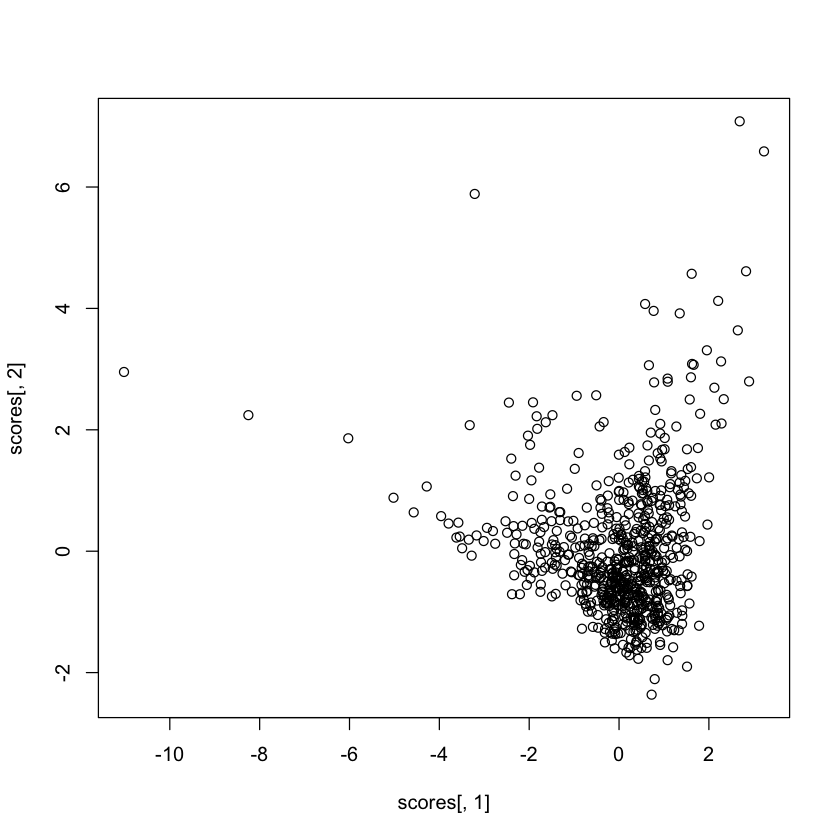

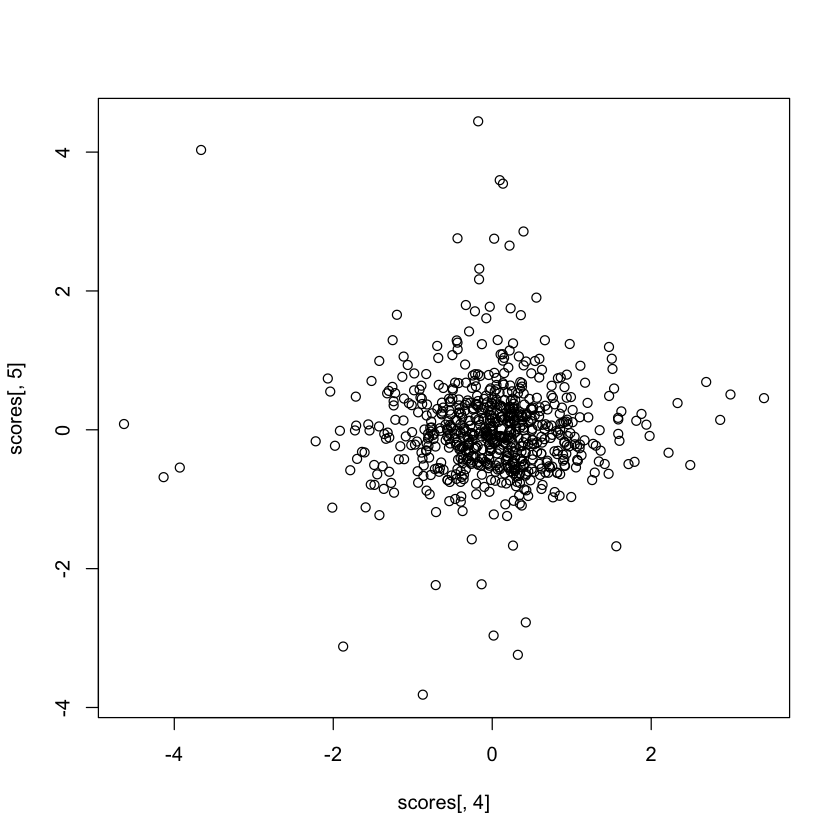

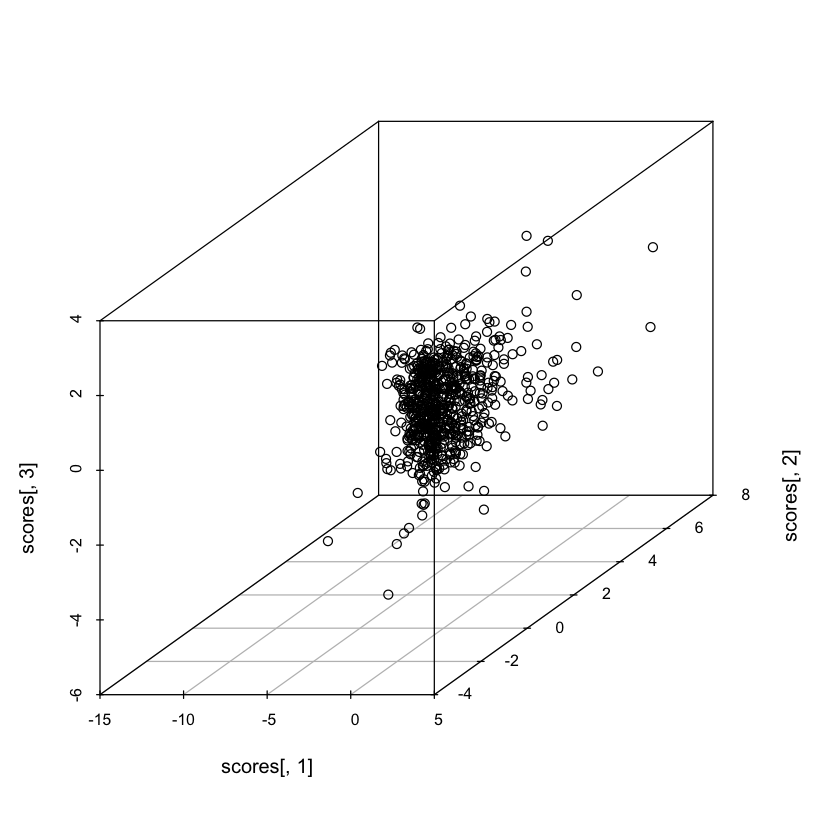

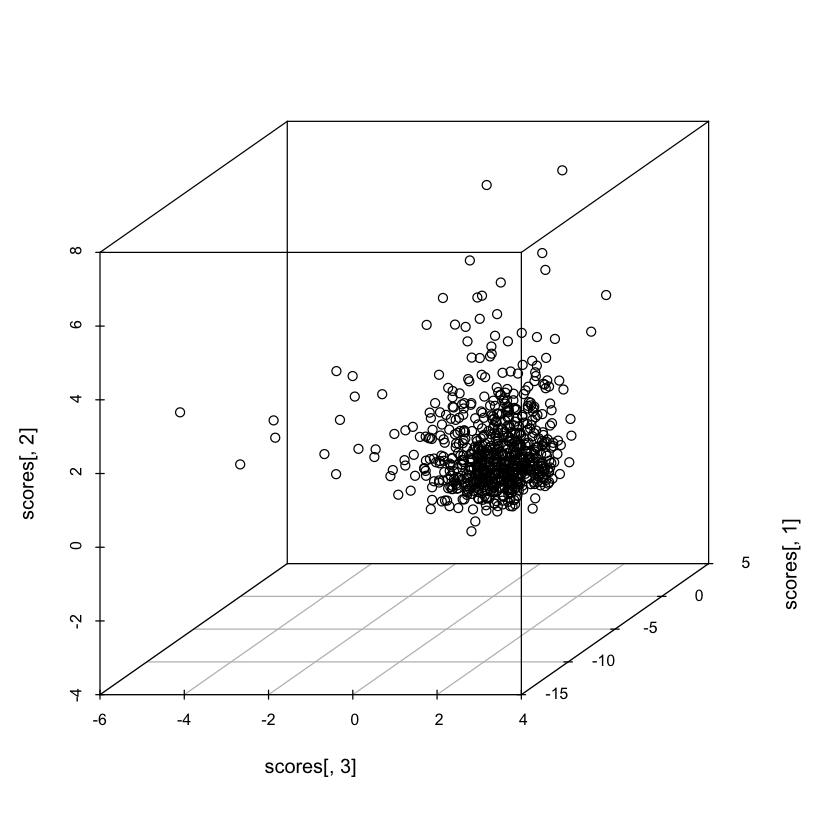

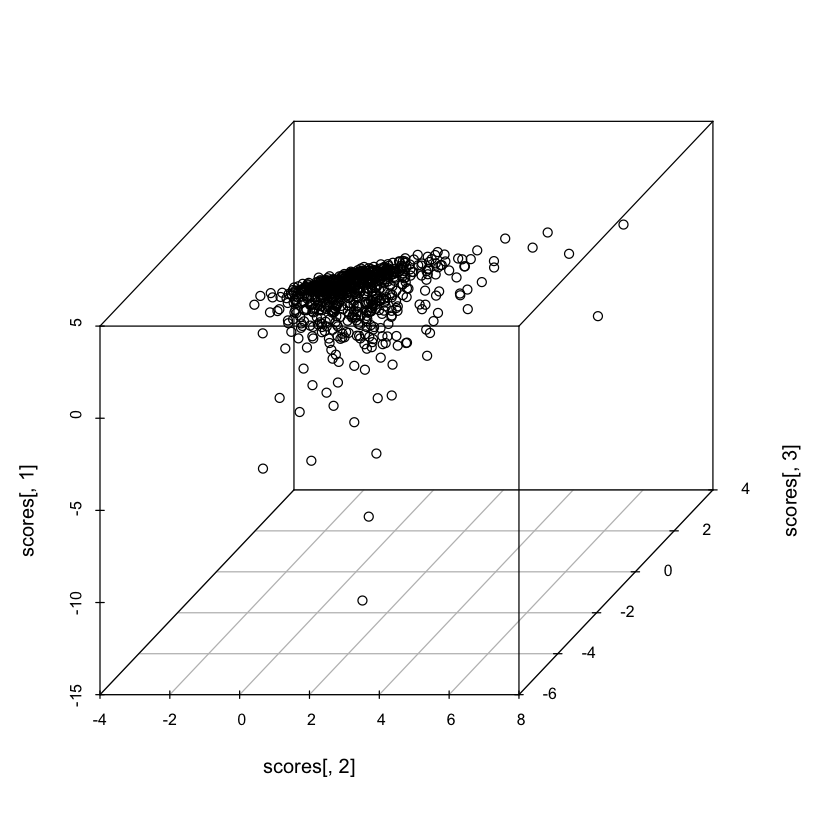

In [46]:
gbsg_quant <- select(gbsg_data, c(size, age, nodes, pgr, er))
cov_gbsg <- cov(scale(gbsg_quant))
eigen_gbsg <- eigen(cov_gbsg)
scores <- scale(gbsg_quant) %*% eigen_gbsg$vectors
colnames(scores) <- c(1,2,3,4,5)
#PCA Plot
plot(scores[,1], scores[,2])
plot(scores[,4], scores[,5])

# 3D Plot for PCA
scatterplot3d(scores[,1], scores[,2], scores[,3])
scatterplot3d(scores[,3], scores[,1], scores[,2])
scatterplot3d(scores[,2], scores[,3], scores[,1])

In [4]:
babies = read.table("/Users/macoscatalina/Desktop/birth_smoke.txt", header=TRUE, sep=" ")
babies$Smoke = factor(babies$Smoke)
head(babies)

,Wgt,Gest,Smoke
,<int>,<int>,<fct>
1,2940,38,yes
2,3130,38,no
3,2420,36,yes
4,2450,34,no
5,2760,39,yes
6,2440,35,yes
